#HW9: The 2-SUM Problem
(Refer to Section 12.2.2)

##Exhaustive Search

In [2]:
def exhaustive_search(array, target):
    for a in array:
        if a == target:
            return target
    return None

In [3]:
# Unit testing
test = [1, 2, 3, 4, 5]

for i in range(len(test)*2 + 2):
    print(str(i) + ": ", end='')
    print(exhaustive_search(test, i))

0: None
1: 1
2: 2
3: 3
4: 4
5: 5
6: None
7: None
8: None
9: None
10: None
11: None


##Sorted Array

In [5]:
def MergeSort(array):
    if len(array) <= 1:
        return array
    else:
        left = MergeSort(array[:len(array)//2])
        right = MergeSort(array[len(array)//2:])
        return Merge(left, right)

def Merge(left, right):
    result = []
    i = 0
    j = 0
    while i < len(left) and j < len(right):
        if left[i] < right[j]:
            result.append(left[i])
            i += 1
        else:
            result.append(right[j])
            j += 1

    while i < len(left):
        result.append(left[i])
        i += 1

    while j < len(right):
        result.append(right[j])
        j += 1

    return result

def binary_search(array, target):
    low_bound = 0
    high_bound = len(array) - 1
    
    while low_bound <= high_bound:
        midpoint = (low_bound + high_bound) // 2
        
        if array[midpoint] == target:
            return midpoint
        elif array[midpoint] < target:
            low_bound = midpoint + 1
        else:
            high_bound = midpoint - 1
    
    return -1

def sorted_array_solution(array, target):
    sorted = MergeSort(array)
    return binary_search(sorted, target)

In [6]:
# Unit testing
test = [1, 2, 3, 4, 5]

for i in range(len(test)*2 + 2):
    print(str(i) + ": ", end='')
    print(sorted_array_solution(test, i))

0: -1
1: 0
2: 1
3: 2
4: 3
5: 4
6: -1
7: -1
8: -1
9: -1
10: -1
11: -1


##Hash Table

In [7]:
def hash_table_solution(array, target):
    hash_map = {}
    
    for i, val in enumerate(array):
        hash_map[val] = i
    
    if target in hash_map:
        return hash_map[target]
    
    return -1


In [8]:
# Unit testing
test = [1, 2, 3, 4, 5]

for i in range(len(test)*2 + 2):
    print(str(i) + ": ", end='')
    print(hash_table_solution(test, i))

0: -1
1: 0
2: 1
3: 2
4: 3
5: 4
6: -1
7: -1
8: -1
9: -1
10: -1
11: -1


##Performance Evaluation

Error: Three solutions do not provide the identical results!
Original Array:  [15796   861  5391 11965 11285  6266 16851  4427 14424 11364 16024  8323
  1686   770  2434  5312  5052  6421 17569 19770  6397  8667 18943 18432
  2748   190 19119  3006  1900  1268 17913 11395  3557  3891  8839 14503
 10628  8793 10556 10254  8434 10234 11017  2613 15788 17160 12207  8227
 14542  3153  1586  3944 19458  1022 11654 10806 13418  7990  9693 12991
  6874  5676   162  4298   996 11535  7630  1017  8530 17263  9269 12186
  6332  8572  7209  5277 18447 16449 16217  8007  2569  2028  2696 15423
  5259  6737   392 13987 12667  5893  3562  6185 19484  8393 13068 15266
 19489  2455 11838 14040]
Target:  38148
Exhausive search:  None
Sorting solution:  -1
Hash table solution:  -1
Error: Three solutions do not provide the identical results!
Original Array:  [19116 10966  9763  5057 14949  8111 13774 17413   503  6911 12686   207
 17869 15935 17248 19175  8756 12384 18142 14821  7575  6375  1679 19627
  

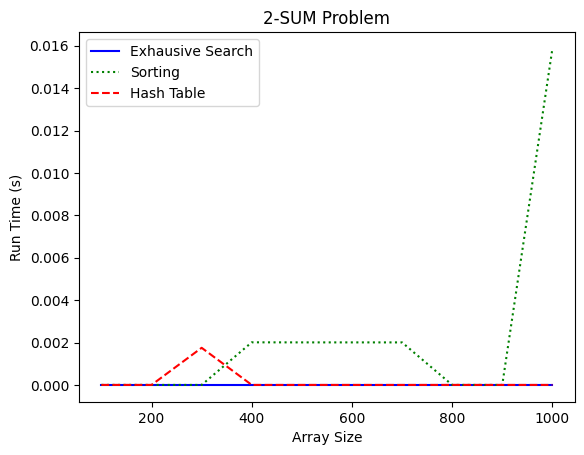

In [9]:
import numpy as np
import time
import matplotlib.pyplot as plt

maxNumber = 20000
startArraySize = 100
endArraySize = 1000
stepArraySize = 100
runsPerSize = 1000

# Generate a random array of a given size
def GenerateRandomArrayAndTarget(size):
    return (np.random.randint(1, maxNumber, size),
            np.random.randint(-maxNumber, 2 * maxNumber))

averageRunTimesExhausive = []
averageRunTimesSorting = []
averageRunTimesHashTable = []

np.random.seed(42)

for arraySize in range(startArraySize, endArraySize+1, stepArraySize):
    runTimesExhausive = []
    runTimesSorting = []
    runTimesHashTable = []

    for run in range(runsPerSize):
        array, target = GenerateRandomArrayAndTarget(arraySize)
        backup_array_1 = array.copy()
        backup_array_2 = array.copy()
        backup_array_3 = array.copy()

        start = time.time()
        resultExhausive = exhaustive_search(backup_array_1, target)
        end = time.time()
        runTimesExhausive.append(end-start)

        start = time.time()
        resultSorting = sorted_array_solution(backup_array_2, target)
        end = time.time()
        runTimesSorting.append(end-start)

        start = time.time()
        resultHashTable = hash_table_solution(backup_array_3, target)
        end = time.time()
        runTimesHashTable.append(end-start)

        if resultExhausive != resultHashTable or resultSorting != resultHashTable:
            print("Error: Three solutions do not provide the identical results!")
            print("Original Array: ", array)
            print("Target: ", target)
            print("Exhausive search: ", resultExhausive)
            print("Sorting solution: ", resultSorting)
            print("Hash table solution: ", resultHashTable)
            break

    averageRunTimesExhausive.append(np.mean(runTimesExhausive))
    averageRunTimesSorting.append(np.mean(runTimesSorting))
    averageRunTimesHashTable.append(np.mean(runTimesHashTable))

x = np.arange(startArraySize, endArraySize+1, stepArraySize)
plt.plot(x, averageRunTimesExhausive, 'b', label='Exhausive Search')
plt.plot(x, averageRunTimesSorting, 'g:', label='Sorting')
plt.plot(x, averageRunTimesHashTable, 'r--', label='Hash Table')
plt.title('2-SUM Problem')
plt.xlabel('Array Size')
plt.ylabel('Run Time (s)')
plt.legend()
plt.show()
